In [1]:
import numpy as np
import matplotlib.pyplot as pl
import scanpy as sc

In [3]:
sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_versions()
results_file = "./write/paul15.h5ad"
# low dpi (dots per inch) yields small inline figures
# sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(3, 3), facecolor="white")

In [4]:
adata = sc.datasets.paul15()
adata

  0%|          | 0.00/9.82M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 2730 × 3451
    obs: 'paul15_clusters'
    uns: 'iroot'

In [5]:
# this is not required and results will be comparable without it
adata.X = adata.X.astype("float64")

In [6]:
sc.pp.recipe_zheng17(adata)

/opt/conda/lib/python3.11/site-packages/scanpy/preprocessing/_recipes.py:185: FutureWarning: Use sc.pp.highly_variable_genes instead
  filter_result = filter_genes_dispersion(


In [7]:
sc.tl.pca(adata, svd_solver="arpack")

In [8]:
sc.pp.neighbors(adata, n_neighbors=4, n_pcs=20)
sc.tl.draw_graph(adata)

/opt/conda/lib/python3.11/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
Package 'fa2-modified' is not installed, falling back to layout 'fr'.To use the faster and better ForceAtlas2 layout, install package 'fa2-modified' (`pip install fa2-modified`).


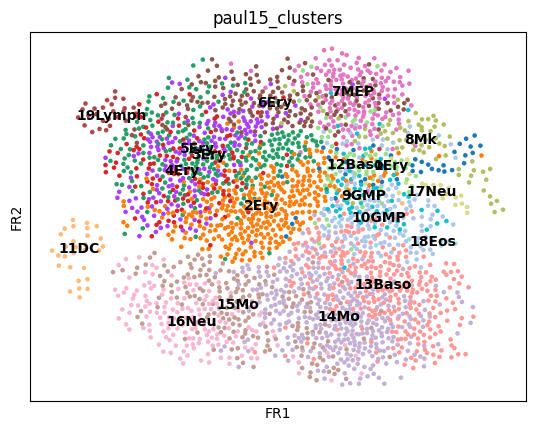

In [9]:
sc.pl.draw_graph(adata, color="paul15_clusters", legend_loc="on data")

# Optional: Denoising the graph

In [10]:
sc.tl.diffmap(adata)
sc.pp.neighbors(adata, n_neighbors=10, use_rep="X_diffmap")

In [11]:
sc.tl.draw_graph(adata)

Package 'fa2-modified' is not installed, falling back to layout 'fr'.To use the faster and better ForceAtlas2 layout, install package 'fa2-modified' (`pip install fa2-modified`).


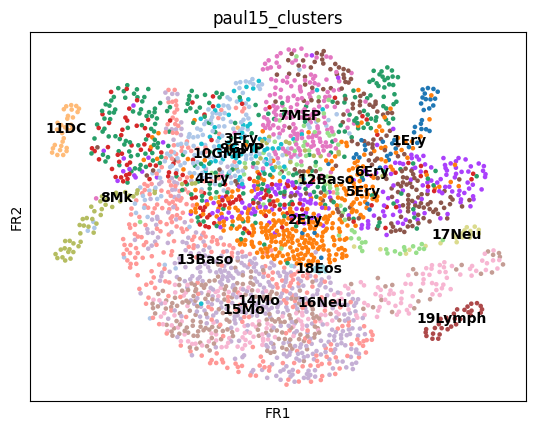

In [12]:
sc.pl.draw_graph(adata, color="paul15_clusters", legend_loc="on data")

# Clustering and PAGA

In [13]:
sc.tl.louvain(adata, resolution=1.0)

In [14]:
sc.tl.paga(adata, groups="louvain")

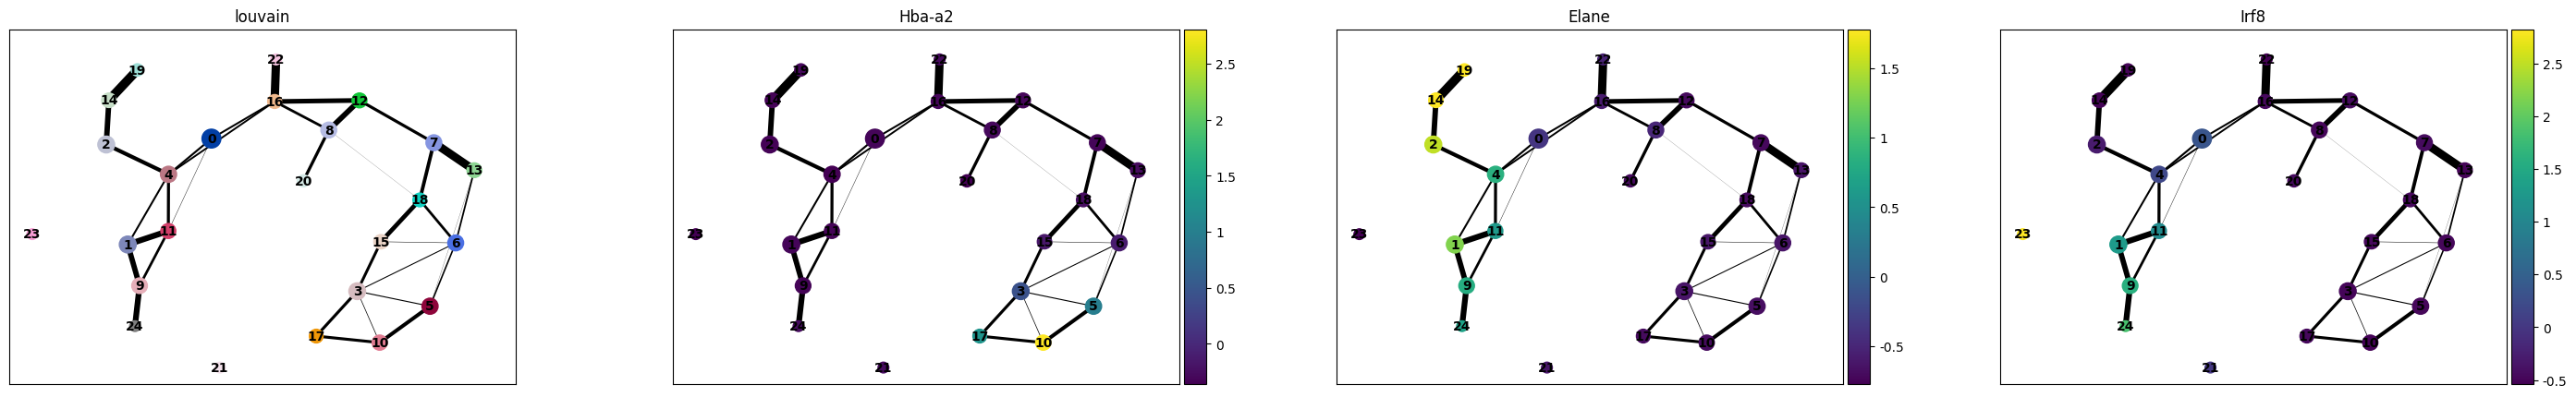

In [15]:
sc.pl.paga(adata, color=["louvain", "Hba-a2", "Elane", "Irf8"])

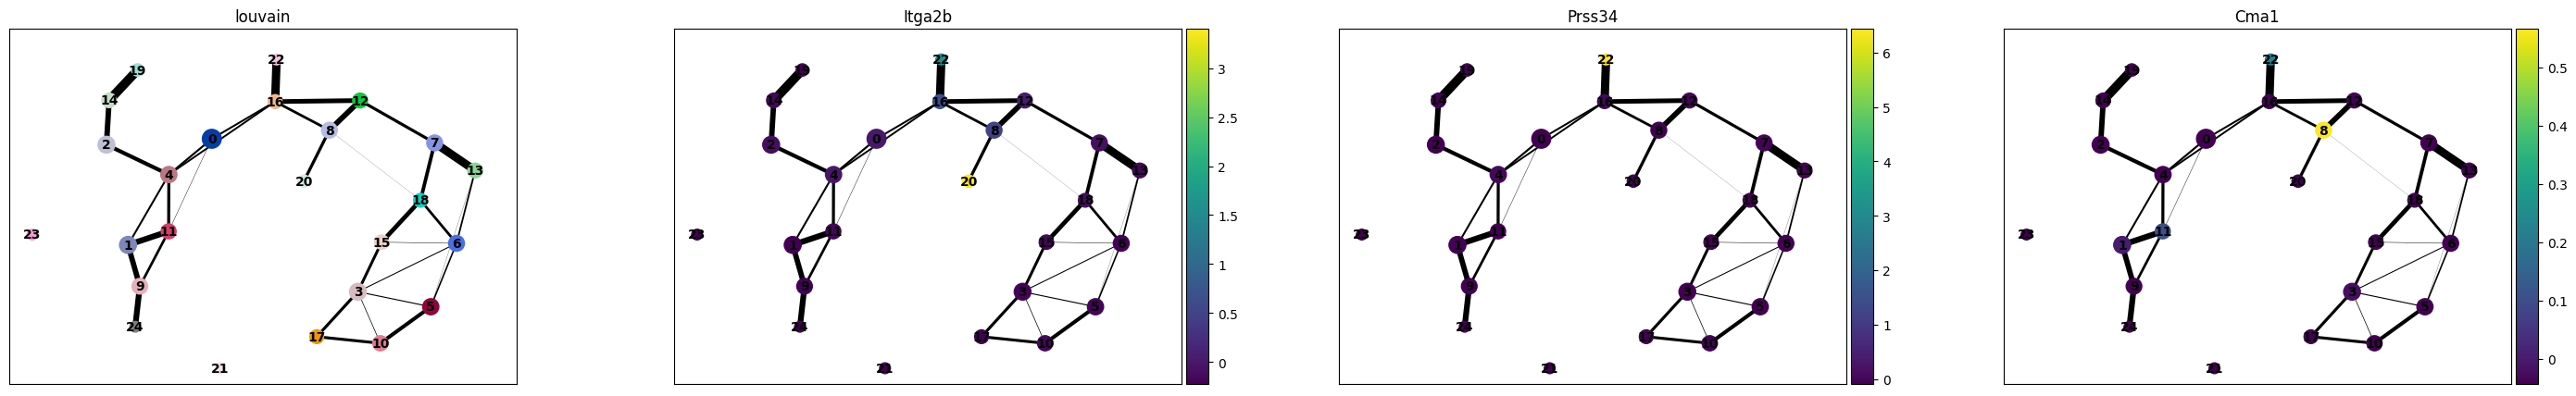

In [16]:
sc.pl.paga(adata, color=["louvain", "Itga2b", "Prss34", "Cma1"])

In [17]:
adata.obs["louvain"].cat.categories

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24'],
      dtype='object')

In [18]:
adata.obs["louvain_anno"] = adata.obs["louvain"].cat.rename_categories(
    {
        "10": "10/Ery",
        "16": "16/Stem",
        "19": "19/Neu",
        "20": "20/Mk",
        "22": "22/Baso",
        "24": "24/Mo",
    }
)

In [19]:
sc.tl.paga(adata, groups="louvain_anno")

<Axes: >

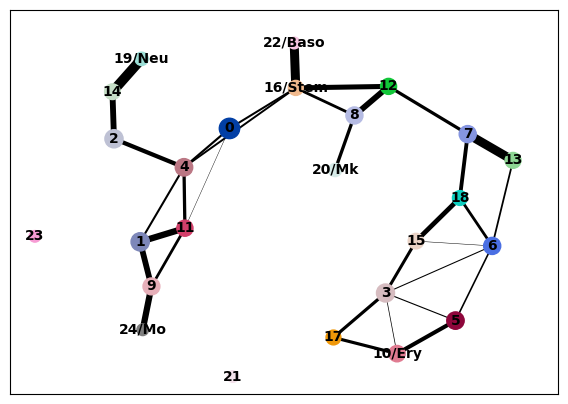

In [20]:
sc.pl.paga(adata, threshold=0.03, show=False)

# Recomputing the embedding using PAGA-initialization

In [21]:
sc.tl.draw_graph(adata, init_pos="paga")

Package 'fa2-modified' is not installed, falling back to layout 'fr'.To use the faster and better ForceAtlas2 layout, install package 'fa2-modified' (`pip install fa2-modified`).


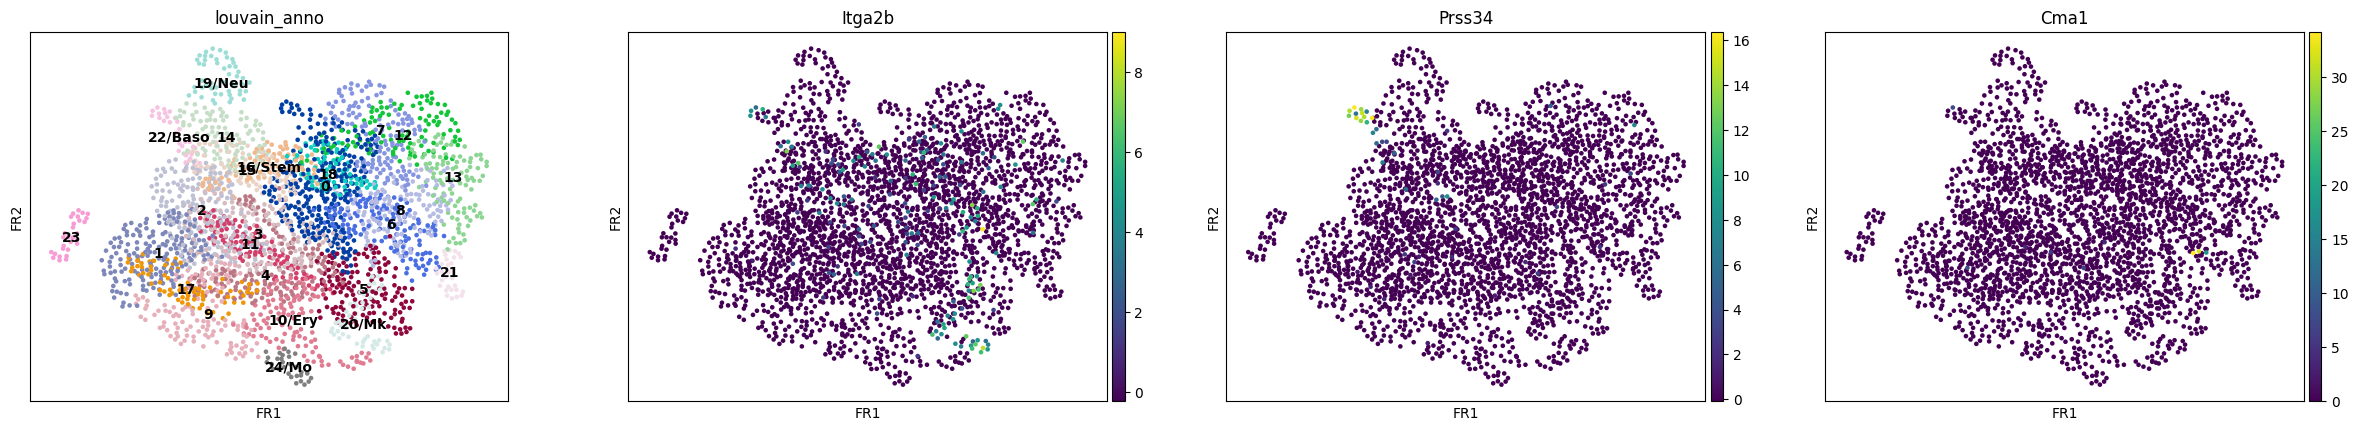

In [22]:
sc.pl.draw_graph(
    adata, color=["louvain_anno", "Itga2b", "Prss34", "Cma1"], legend_loc="on data"
)

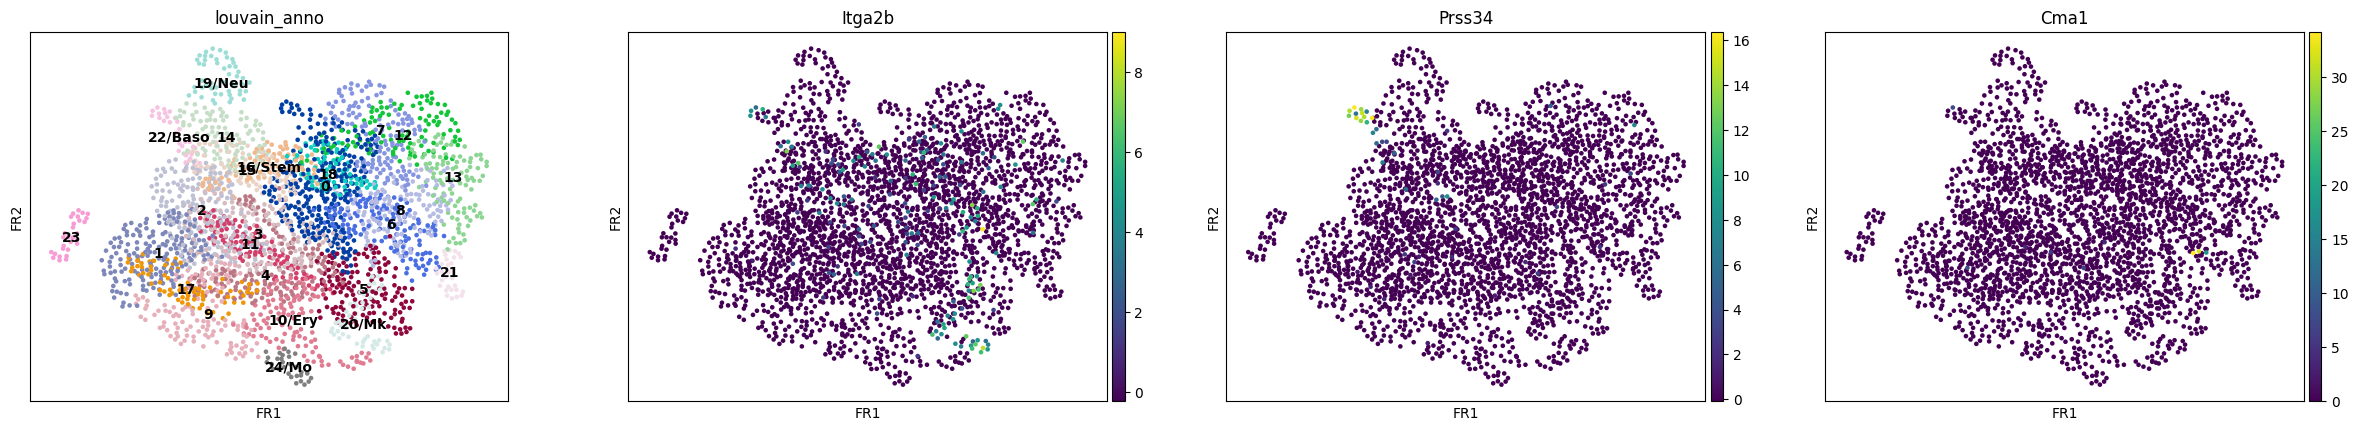

In [23]:
sc.pl.draw_graph(
    adata, color=["louvain_anno", "Itga2b", "Prss34", "Cma1"], legend_loc="on data"
)

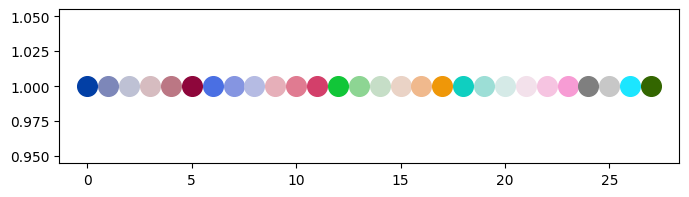

In [24]:
pl.figure(figsize=(8, 2))
for i in range(28):
    pl.scatter(i, 1, c=sc.pl.palettes.zeileis_28[i], s=200)
pl.show()

In [25]:
zeileis_colors = np.array(sc.pl.palettes.zeileis_28)
new_colors = np.array(adata.uns["louvain_anno_colors"])

In [26]:
new_colors[[16]] = zeileis_colors[[12]]  # Stem colors / green
new_colors[[10, 17, 5, 3, 15, 6, 18, 13, 7, 12]] = zeileis_colors[  # Ery colors / red
    [5, 5, 5, 5, 11, 11, 10, 9, 21, 21]
]
new_colors[[20, 8]] = zeileis_colors[[17, 16]]  # Mk early Ery colors / yellow
new_colors[[4, 0]] = zeileis_colors[[2, 8]]  # lymph progenitors / grey
new_colors[[22]] = zeileis_colors[[18]]  # Baso / turquoise
new_colors[[19, 14, 2]] = zeileis_colors[[6, 6, 6]]  # Neu / light blue
new_colors[[24, 9, 1, 11]] = zeileis_colors[[0, 0, 0, 0]]  # Mo / dark blue
new_colors[[21, 23]] = zeileis_colors[[25, 25]]  # outliers / grey

In [27]:
adata.uns["louvain_anno_colors"] = new_colors

saving figure to file figures/paga_compare.pdf


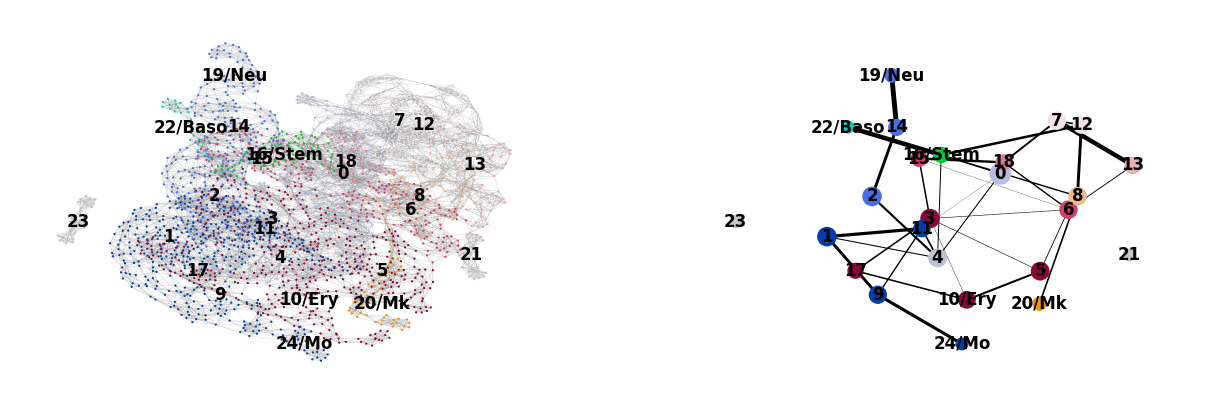

[<Axes: xlabel='FR1', ylabel='FR2'>, <Axes: >]

In [28]:
sc.pl.paga_compare(
    adata,
    threshold=0.03,
    title="",
    right_margin=0.2,
    size=10,
    edge_width_scale=0.5,
    legend_fontsize=12,
    fontsize=12,
    frameon=False,
    edges=True,
    save=True,
)

# Reconstructing gene changes along PAGA paths for a given set of genes

In [29]:
adata.uns["iroot"] = np.flatnonzero(adata.obs["louvain_anno"] == "16/Stem")[0]


In [30]:
sc.tl.dpt(adata)


In [31]:
gene_names = [
    *["Gata2", "Gata1", "Klf1", "Epor", "Hba-a2"],  # erythroid
    *["Elane", "Cebpe", "Gfi1"],  # neutrophil
    *["Irf8", "Csf1r", "Ctsg"],  # monocyte
]

In [32]:
adata_raw = sc.datasets.paul15()
sc.pp.log1p(adata_raw)
sc.pp.scale(adata_raw)
adata.raw = adata_raw

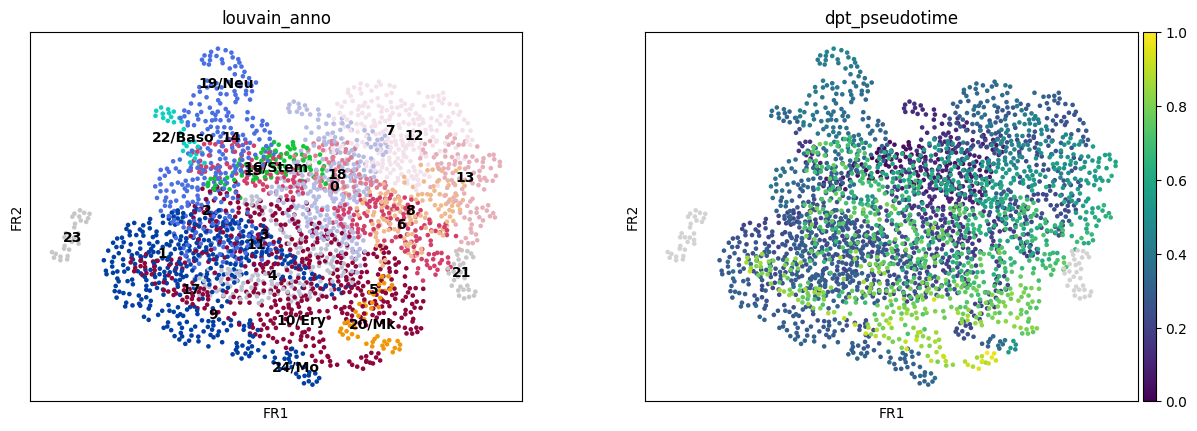

In [33]:
sc.pl.draw_graph(adata, color=["louvain_anno", "dpt_pseudotime"], legend_loc="on data")

In [34]:
paths = [
    ("erythrocytes", [16, 12, 7, 13, 18, 6, 5, 10]),
    ("neutrophils", [16, 0, 4, 2, 14, 19]),
    ("monocytes", [16, 0, 4, 11, 1, 9, 24]),
]

In [35]:
adata.obs["distance"] = adata.obs["dpt_pseudotime"]

In [36]:
adata.obs["clusters"] = adata.obs["louvain_anno"]  # just a cosmetic change

In [37]:
adata.uns["clusters_colors"] = adata.uns["louvain_anno_colors"]

In [38]:
!mkdir write

/opt/conda/lib/python3.11/site-packages/scanpy/plotting/_tools/paga.py:1292: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  groups_axis.set_yticklabels(["", xlabel, ""], fontsize=ytick_fontsize)
/opt/conda/lib/python3.11/site-packages/scanpy/plotting/_tools/paga.py:1334: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  anno_axis.set_yticklabels(["", anno, ""], fontsize=ytick_fontsize)


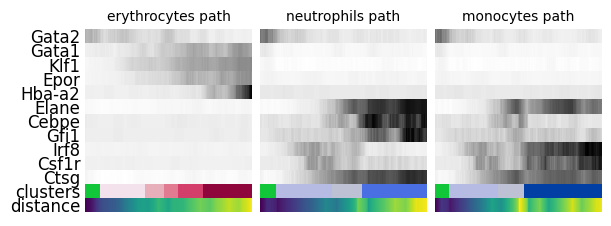

In [39]:
_, axs = pl.subplots(
    ncols=3, figsize=(6, 2.5), gridspec_kw={"wspace": 0.05, "left": 0.12}
)
pl.subplots_adjust(left=0.05, right=0.98, top=0.82, bottom=0.2)
for ipath, (descr, path) in enumerate(paths):
    data = sc.pl.paga_path(
        adata,
        path,
        gene_names,
        show_node_names=False,
        ax=axs[ipath],
        ytick_fontsize=12,
        left_margin=0.15,
        n_avg=50,
        annotations=["distance"],
        show_yticks=True if ipath == 0 else False,
        show_colorbar=False,
        color_map="Greys",
        groups_key="clusters",
        color_maps_annotations={"distance": "viridis"},
        title="{} path".format(descr),
        return_data=True,
        show=False,
    )
    data.to_csv("./write/paga_path_{}.csv".format(descr))
pl.savefig("./figures/paga_path_paul15.pdf")
pl.show()